<a href="https://colab.research.google.com/github/ML4SCI/ML4SCIHackathon/blob/main/HiggsBosonClassificationChallenge/higgs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**This is an example Notebook for running training on Higgs vs background signal classification. **

**Background:** High-energy collisions at the Large Hadron Collider (LHC) produce particles that interact with particle detectors. One important task is to classify different types of collisions based on their physics content, allowing physicists to find patterns in the data and to potentially unravel new discoveries.

**Problem statement:** The discovery of the Higgs boson by CMS and ATLAS Collaborations was announced at CERN in 2012. In this work, we focus on the potential of Quantum Machine Learning (QML) in detecting potential Higgs signal from one of the background processes that mimics it. This notebook imeplements a classical neural network for this task as an example, and your goal is to develop a quantum architecture to classify the Higgs signal.

**Dataset:** The dataset is made available by the Center for Machine Learning and Intelligent Systems at University of California, Irvine.
The full dataset can be found on the [UCI Machine learning Repository](https://archive.ics.uci.edu/ml/datasets/HIGGS). Here, we are going to use a reduced dataset for training and validation, and the final results will be evaluated on a separate test set after the submission.

**Description:** The dataset consists of a total of 11 million labeled samples of Higgs vs background events produced by Monte Carlo simulations. Each sample consists of 28 features. The first 21 features are kinematic properties measured at the level of the detectors. The last seven are functions of the first 21.




**Steps to load the training dataset**
1. Download the dataset from the UCI website.

2. Unzip the dataset folder

In [518]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim

from sklearn.datasets import make_gaussian_quantiles
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import pandas as pd

import copy
import time

import pennylane as qml
from pennylane.optimize import NesterovMomentumOptimizer
from pennylane import numpy as np


**Load the file using pandas library**

In [519]:
data=pd.read_csv('data/challenge_higgs_data.csv')

Assign first column 0 to class labels (labeled 1 for signal, 0 for background)  and all others to feature matrix X.

In this example, for the sake of fast checking, we use 1000 samples. To train on the entire dataset, proceed with uncommenting the lines below.

In [520]:
X=data.iloc[:1000,1:]#data.iloc[:,1:]
y=data.iloc[:1000,0]#data.iloc[:,0]

Split your data into training and validation samples where the fraction of the data used for validation is 20%.

In [521]:
X_train1, X_val, y_train1, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_train1, y_train1, test_size=0.2, random_state=42)

# Convert to torch tensors
X_train_tensor = np.array(X_train.values)
y_train_tensor = (np.array(y_train.values)-0.5)*2

X_val_tensor = np.array(X_val.values)
y_val_tensor = (np.array(y_val.values)-0.5)*2

X_test_tensor = np.array(X_test.values)
y_test_tensor = (np.array(y_test.values)-0.5)*2

# Create TensorDatasets
#train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
#test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 32

"""dataloaders = {
    "train": DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    "validation": DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    "test": DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
}

dataset_sizes = {"train": len(train_dataset),
                 "validation": len(val_dataset),
                 "test": len(test_dataset)}"""

'dataloaders = {\n    "train": DataLoader(train_dataset, batch_size=batch_size, shuffle=True),\n    "validation": DataLoader(val_dataset, batch_size=batch_size, shuffle=False),\n    "test": DataLoader(test_dataset, batch_size=batch_size, shuffle=False)\n}\n\ndataset_sizes = {"train": len(train_dataset),\n                 "validation": len(val_dataset),\n                 "test": len(test_dataset)}'

**Visualize your data - One histogram per feature column**

Detailed information on what each feature column is can be found in *Attribute Information* section on the [UCI Machine learning Repositery](https://archive.ics.uci.edu/ml/datasets/HIGGS). For further information, refer to the [paper](https://www.nature.com/articles/ncomms5308) by Baldi et. al

**Setup the Neural Network** (some useful info [here](https://towardsdatascience.com/a-gentle-introduction-to-neural-networks-series-part-1-2b90b87795bc))

In [522]:
dev = qml.device("default.qubit") # torch, classical device

In [523]:
def W(n_qubits, layer_weights):
    """
    Parameterized trainable layer.

    2-D Numpy Array: numpy.Array([[0.1, 1.57, 0.9],
                                    [0.4, 1.2, 0.3]])
    """
    for wire in range(n_qubits+1):
        qml.Rot(*layer_weights[wire], wires=wire)

    for wire in range(n_qubits):
        qml.CNOT(wires=[wire, wire+1])

    qml.CNOT(wires=[n_qubits, 0])

    """for i in range(n_qubits):
        for j in range(n_qubits):
            if i != j:
                qml.CNOT(wires=[i, j])"""


def S(x, n_qubits):
    """
    Encode classical data with a unitary operation.

    This is a PQC with 2 qubits:
        - Encode by rotating around Y for qubit 1 (feature 1).
        - Encode by rotating around Y for qubit 2 (feature 2).
        - We also add an entangling layer, which is a nonclassical operation, natural to quantum computers.
    """
    for wire in range(n_qubits+1):
        qml.Hadamard(wire)

    for wire in range(n_qubits):
        qml.RZ(x[wire], wires=wire)
        qml.RX(x[2*wire], wires=wire)
    
    for wire in range(n_qubits):
        qml.CNOT(wires=[wire, wire+1])

    qml.CNOT(wires=[n_qubits, 0])

@qml.qnode(dev)
def circuit(weights, x, n_qubits):
    S(x, n_qubits)

    for layer_weights in weights:
        W(n_qubits, layer_weights)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits+1)]

def variational_classifier(weights, bias, n_qubits, x):
    return np.mean(np.array(circuit(weights, x, n_qubits)), axis=0) + bias


def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


def cost(weights, bias, n_qubits, X, Y):
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, n_qubits, X.T)
    return square_loss(Y, predictions)


def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

In [524]:
num_qubits = 14
num_layers = 3

weights_init = 0.01 * np.random.randn(num_layers, num_qubits+1, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)
print(weights_init[0,0])

[ 0.00015291  0.01846407 -0.00144179]


In [525]:
def find_basis(X, num_dim=3):
    X = X - np.mean(X, axis=0)
    normalization = np.sqrt(np.sum(X**2, -1))
    X = (X.T / normalization).T

    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    projection_matrix = Vt[:num_dim].T

    return projection_matrix


def preprocessing(X, proj_matrix):
    X = X - np.mean(X, axis=0)
    normalization = np.sqrt(np.sum(X**2, -1))
    X = (X.T / normalization).T

    features = X @ proj_matrix
    return features



In [526]:
proj_matrix = find_basis(X_train_tensor, num_dim=2*num_qubits)

feats_train = preprocessing(X_train_tensor, proj_matrix)
Y_train = y_train_tensor
feats_val = preprocessing(X_val_tensor, proj_matrix)
Y_val = y_val_tensor
feats_test = preprocessing(X_test_tensor, proj_matrix)
Y_test = y_test_tensor

print(y_test_tensor.shape)
print(feats_test.shape)

(160,)
(160, 28)


(<Figure size 6900x1600 with 1 Axes>, <Axes: >)
(640, 28)


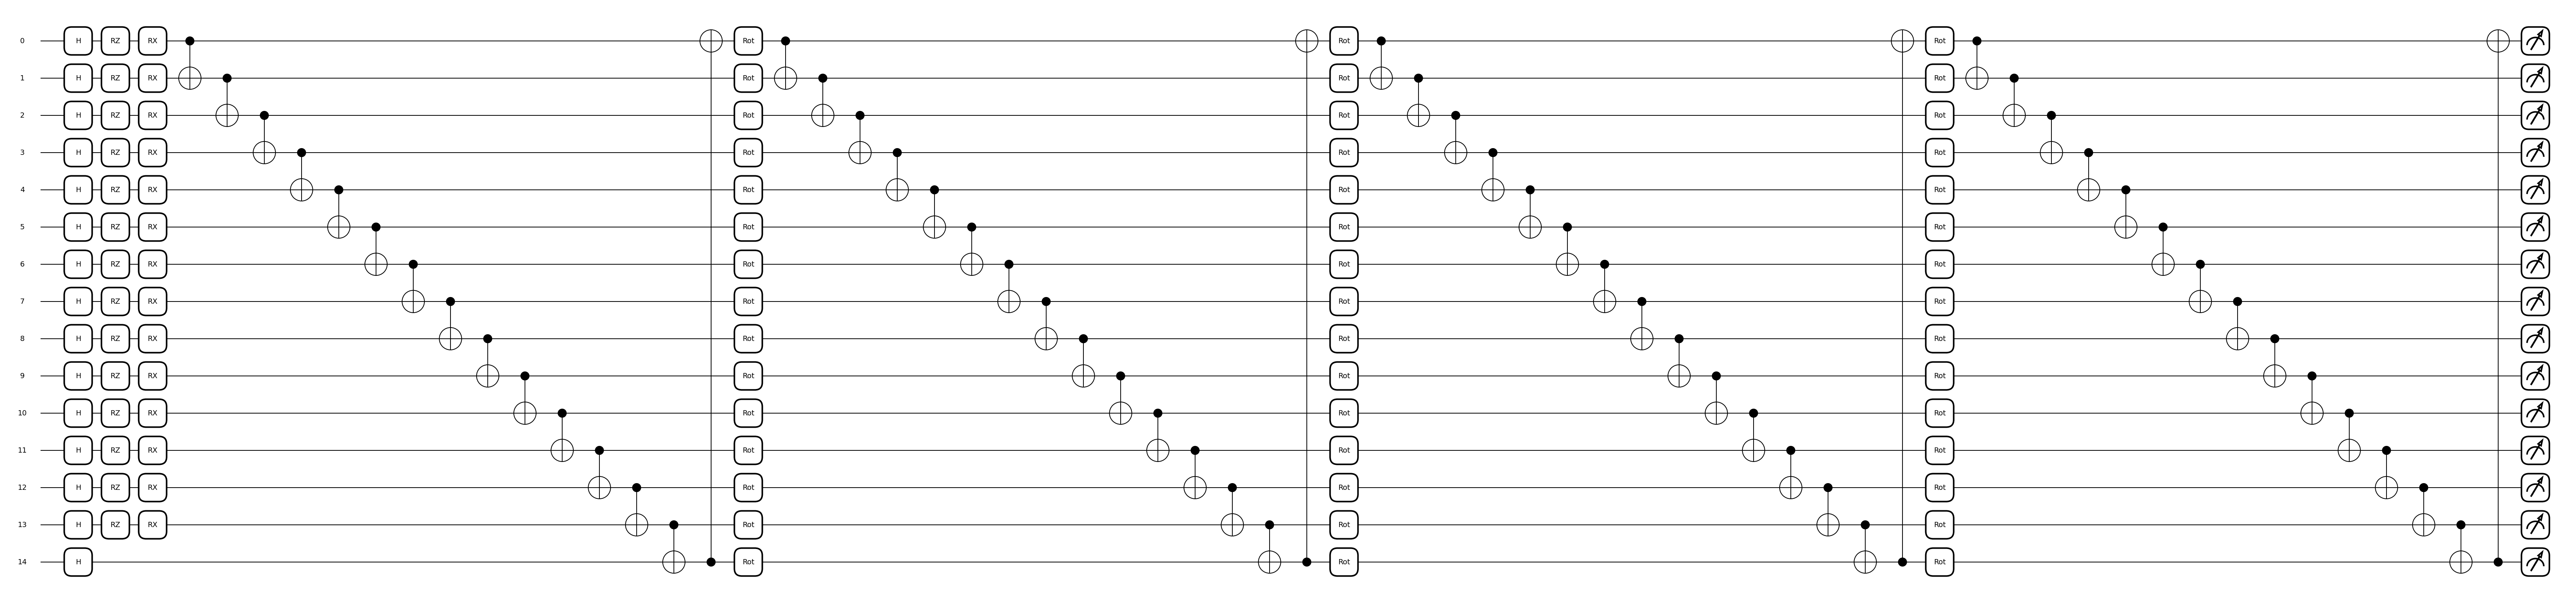

In [527]:
print(qml.draw_mpl(circuit)(weights_init, feats_train, num_qubits))
print(feats_train.shape)

In [528]:
#np.random.seed(42)
num_data = len(y_train_tensor)
index = np.random.permutation(range(num_data))

opt = NesterovMomentumOptimizer(0.5)
batch_size = 32

# train the variational classifier
weights = weights_init
bias = bias_init
for it in range(60):
    # Update the weights by one optimizer step
    batch_index = np.random.randint(0, num_data, (batch_size,))
    feats_train_batch = feats_train[batch_index]
    Y_train_batch = Y_train[batch_index]
    weights, bias, _, _, _ = opt.step(cost, weights, bias, num_qubits, feats_train_batch, Y_train_batch)

    # Compute predictions on train and validation set
    predictions_train = np.sign(variational_classifier(weights, bias, num_qubits, feats_train.T))
    predictions_val = np.sign(variational_classifier(weights, bias, num_qubits, feats_val.T))

    # Compute accuracy on train and validation set
    acc_train = accuracy(Y_train, predictions_train)
    acc_val = accuracy(Y_val, predictions_val)

    if (it + 1) % 2 == 0:
        _cost = cost(weights, bias, num_qubits, feats_test, Y_test)
        print(
            f"Iter: {it + 1:5d} | Cost: {_cost:0.7f} | "
            f"Acc train: {acc_train:0.7f} | Acc validation: {acc_val:0.7f}"
        )

Iter:     2 | Cost: 1.0020001 | Acc train: 0.5109375 | Acc validation: 0.4600000
Iter:     4 | Cost: 1.0054865 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:     6 | Cost: 1.0528956 | Acc train: 0.5109375 | Acc validation: 0.4600000
Iter:     8 | Cost: 1.0178313 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    10 | Cost: 1.0192580 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    12 | Cost: 1.0018200 | Acc train: 0.5109375 | Acc validation: 0.4600000
Iter:    14 | Cost: 1.0406101 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    16 | Cost: 1.0075001 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    18 | Cost: 1.0000451 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    20 | Cost: 1.0391829 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    22 | Cost: 1.0182776 | Acc train: 0.4890625 | Acc validation: 0.5400000
Iter:    24 | Cost: 1.0286596 | Acc train: 0.5109375 | Acc validation: 0.4600000
Iter:    26 | Cost: 1.062451

In [529]:
y_pred = variational_classifier(weights, bias, num_qubits, feats_test.T)
y_true = Y_test


**Print confusion matrix which describes the performance of the model classification by displaying the number of True Positives, True Negatives, False Positives and False Negatives. More info on [Wikipedia](https://en.wikipedia.org/wiki/Confusion_matrix)**

**Plot the ROC (Receiver Operating Characteristic) Curve** (more info on ROC could be found [here](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)

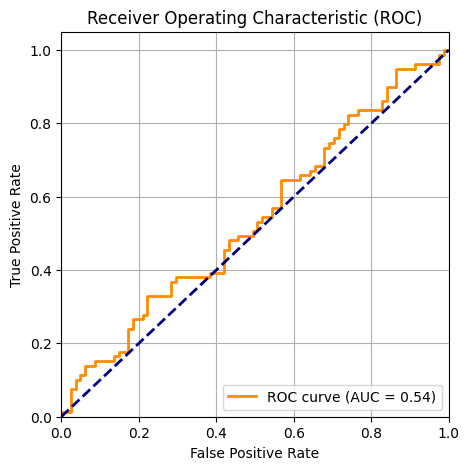

In [530]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# If y_test and y_pred are class labels (e.g., 0/1), you'll need predicted probabilities too.
# y_prob should be the predicted probability for the positive class (usually 1)
# Example: y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Deliverables**

Please submit the following:

*   Your full notebook used for training including the ROC Curves, model weights and loss and accuracy plots wrt number of epochs.




**References**

Baldi, P., Sadowski, P. and Whiteson, D. “Searching for Exotic Particles in High-energy Physics with Deep Learning.” Nature Communications 5 (July 2, 2014).



**Contributors**

Sergei V. Gleyzer *(University of Alabama)*

Jogi Suda Neto *(University of Alabama)*

Marco Knipfer *(University of Alabama)*

Gopal Ramesh Dahale *(EPFL)*

Ali Hariri *(EPFL)*

Eric Reinhardt *(University of Alabama)*